# Train REINFORCE

REINFORCE learns a stochastic policy from complete-episode returns. This notebook trains it on `CartPole-v1` with a categorical policy for the two discrete actions and a learned value baseline to reduce gradient variance.

In [1]:
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

from aprenderl import REINFORCE, REINFORCEConfig
from aprenderl.utils import evaluate_policy

ENV_ID = "CartPole-v1"

In [2]:
env = gym.make(ENV_ID)
config = REINFORCEConfig(
    learning_rate=1e-2,
    gamma=0.99,
    episodes_per_update=5,
    use_baseline=True,
    normalize_returns=True,
)

agent = REINFORCE(env, config=config, device="cpu")
agent.learn(total_timesteps=20_000)
env.close()

REINFORCE:   0%|          | 0/20000 [00:00<?, ?step/s]

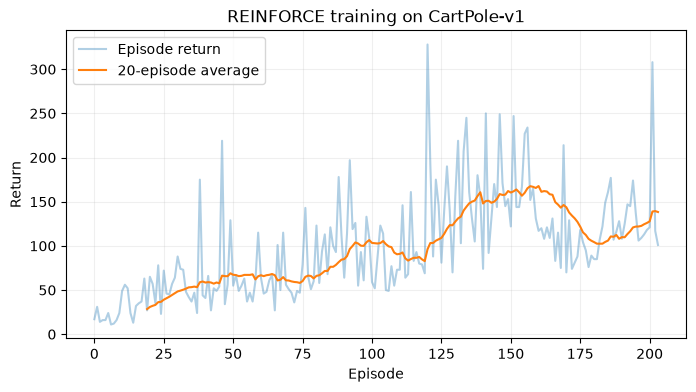

In [3]:
returns = np.asarray(agent.episode_returns)
window = min(20, len(returns))
moving_average = np.convolve(returns, np.ones(window) / window, mode="valid")

plt.figure(figsize=(8, 4))
plt.plot(returns, alpha=0.35, label="Episode return")
plt.plot(
    np.arange(window - 1, len(returns)),
    moving_average,
    label=f"{window}-episode average",
)
plt.xlabel("Episode")
plt.ylabel("Return")
plt.title(f"REINFORCE training on {ENV_ID}")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## Watch the trained policy

This opens a window and runs 5 episodes using deterministic actions.

In [4]:
evaluation_env = gym.make(ENV_ID, render_mode="human")
try:
    result = evaluate_policy(agent, evaluation_env, episodes=5)
finally:
    evaluation_env.close()

print("Episode returns:", result.returns)
print(f"Mean return: {result.mean_return:.1f} +/- {result.return_std:.1f}")

Episode returns: (500.0, 381.0, 338.0, 133.0, 169.0)
Mean return: 304.2 +/- 136.4
